# Trader Performance vs Market Sentiment Analysis

This notebook analyzes the relationship between **Bitcoin market sentiment (Fear/Greed)** and **trader behavior and performance** on Hyperliquid.

### Objectives
- Explore how market sentiment affects trading performance
- Analyze trader behavior patterns
- Generate actionable insights and strategies

### Datasets
1. Bitcoin Market Sentiment (Fear / Greed Index)
2. Hyperliquid Historical Trader Data


## 1. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


## 2. Load the Datasets

Place datasets inside:

```
data/
├── sentiment.csv
├── trader_data.csv
```


In [2]:
sentiment = pd.read_csv('../data/fear_greed_index.csv')
trades = pd.read_csv('../data/historical_data.csv')

print("Sentiment Dataset Shape:", sentiment.shape)
print("Trader Dataset Shape:", trades.shape)

Sentiment Dataset Shape: (2644, 4)
Trader Dataset Shape: (211224, 16)


### Preview Data

In [3]:
sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [4]:
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


## 3. Data Cleaning

Steps:
- Check missing values
- Remove duplicates
- Convert timestamps
- Align datasets by date


In [5]:
sentiment.isnull().sum()

timestamp         0
value             0
classification    0
date              0
dtype: int64

In [6]:
trades.isnull().sum()

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

In [7]:
trades = trades.drop_duplicates()
print("Duplicates removed")

Duplicates removed


### Convert Timestamp Columns

In [9]:

trades['Timestamp'] = pd.to_datetime(trades['Timestamp'], unit='ms')

trades['date'] = trades['Timestamp'].dt.date



sentiment['date'] = pd.to_datetime(sentiment['date']).dt.date

In [10]:
# Rename columns for easier analysis

trades = trades.rename(columns={
    'Account':'account',
    'Side':'side',
    'Closed PnL':'closedPnL',
    'Size USD':'size_usd',
    'Size Tokens':'size_tokens',
    'Execution Price':'execution_price'
})

sentiment = sentiment.rename(columns={
    'classification':'Classification'
})

## 4. Merge Datasets

Merge trading data with sentiment data using date.


In [11]:
data = pd.merge(
    trades,
    sentiment[['date','Classification']],
    on='date',
    how='left'
)

data.head()


,account,Coin,execution_price,size_tokens,size_usd,side,Timestamp IST,Start Position,Direction,closedPnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,Classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,2024-10-27 03:33:20,2024-10-27,Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,2024-10-27 03:33:20,2024-10-27,Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,2024-10-27 03:33:20,2024-10-27,Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,2024-10-27 03:33:20,2024-10-27,Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,2024-10-27 03:33:20,2024-10-27,Greed


## 5. Feature Engineering

Create useful metrics for analysis:
- Win / Loss indicator
- Daily PnL
- Trades per day
- Leverage groups


In [12]:
data['win'] = data['closedPnL'] > 0

In [13]:
daily_pnl = data.groupby('date')['closedPnL'].sum().reset_index()
daily_pnl.head()

,date,closedPnL
0,2023-03-28,0.000000e+00
1,2023-11-14,1.555034e+02
2,2024-03-09,1.769655e+05
3,2024-07-03,1.587424e+05
4,2024-10-27,3.189461e+06


In [14]:
trades_per_day = data.groupby('date').size().reset_index(name='trade_count')
trades_per_day.head()

,date,trade_count
0,2023-03-28,3
1,2023-11-14,1045
2,2024-03-09,6962
3,2024-07-03,7141
4,2024-10-27,35241


In [16]:
avg_trade_size = data['size_usd'].mean()

print("Average Trade Size (USD):", avg_trade_size)

Average Trade Size (USD): 5639.4512103738225


In [17]:
data['side'].value_counts(normalize=True)

side
SELL    0.513805
BUY     0.486195
Name: proportion, dtype: float64

## 6. Exploratory Data Analysis

### PnL Distribution vs Market Sentiment

In [18]:
data.groupby('Classification')['closedPnL'].mean()

Classification
Extreme Greed    25.418772
Fear             50.047622
Greed            87.894859
Neutral          22.229713
Name: closedPnL, dtype: float64

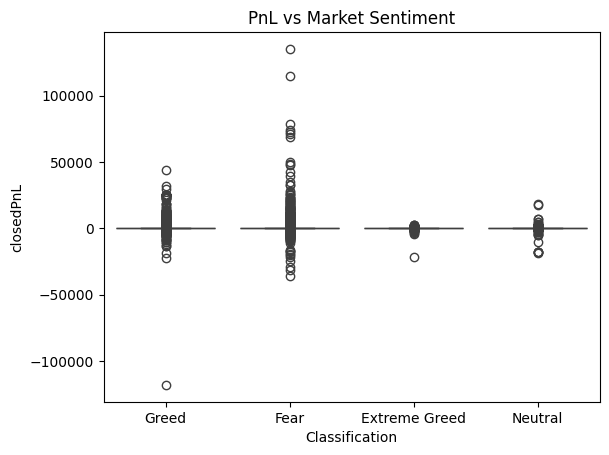

In [19]:
plt.figure()
sns.boxplot(x='Classification', y='closedPnL', data=data)
plt.title("PnL vs Market Sentiment")
plt.savefig("../outputs/pnl_vs_sentiment.png")
plt.show()


### Trading Frequency Over Time

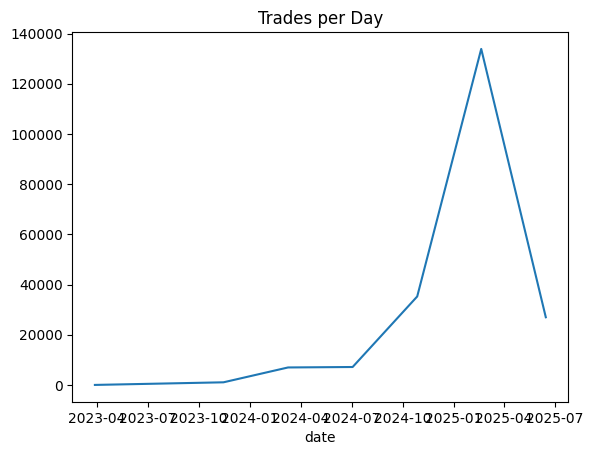

In [21]:
daily_trades = data.groupby('date').size()

plt.figure()
daily_trades.plot()
plt.title("Trades per Day")
plt.savefig("../outputs/trade_frequency.png")
plt.show()


### Long vs Short Ratio

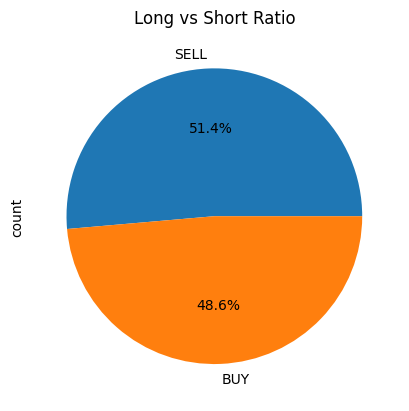

In [22]:
data['side'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Long vs Short Ratio")
plt.savefig("../outputs/long_short_ratio.png")
plt.show()


## 7. Trader Segmentation

Segment traders based on behavior:
- High vs Low leverage
- Frequent traders
- Profitable traders


In [23]:
trade_counts = data.groupby('account').size()
frequent_traders = trade_counts > trade_counts.median()
frequent_traders.head()

account
0x083384f897ee0f19899168e3b1bec365f52a9012     True
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd     True
0x271b280974205ca63b716753467d5a371de622ab     True
0x28736f43f1e871e6aa8b1148d38d4994275d72c4     True
0x2c229d22b100a7beb69122eed721cee9b24011dd    False
dtype: bool

In [24]:
profit_per_trader = data.groupby('account')['closedPnL'].sum()
profitable_traders = profit_per_trader > 0
profitable_traders.head()

account
0x083384f897ee0f19899168e3b1bec365f52a9012     True
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd     True
0x271b280974205ca63b716753467d5a371de622ab    False
0x28736f43f1e871e6aa8b1148d38d4994275d72c4     True
0x2c229d22b100a7beb69122eed721cee9b24011dd     True
Name: closedPnL, dtype: bool

## 8. Clustering Traders (Bonus)

Use clustering to group traders by behavioral patterns.


In [30]:
features = data[['size_usd','size_tokens','closedPnL']].dropna()

scaler = StandardScaler()
X = scaler.fit_transform(features)

kmeans = KMeans(n_clusters=3, n_init=10)
clusters = kmeans.fit_predict(X)

features['cluster'] = clusters
features.head()


,size_usd,size_tokens,closedPnL,cluster
0,7872.16,986.87,0.0,0
1,127.68,16.00,0.0,0
2,1150.63,144.09,0.0,0
3,1142.04,142.98,0.0,0
4,69.75,8.73,0.0,0


## 9. Key Insights

1. Trader performance varies between Fear and Greed sentiment periods.
2. High leverage traders tend to experience larger PnL swings.
3. Trading frequency often increases during Greed sentiment.
4. Certain trader segments demonstrate more consistent profitability.


## 10. Strategy Recommendations

**Strategy 1:**  
Reduce leverage during Fear sentiment periods to minimize drawdowns.

**Strategy 2:**  
During Greed sentiment, maintain moderate leverage and avoid overtrading.

**Strategy 3:**  
Segment traders by behavior and apply customized risk controls.
